# SurvivalNet STAD Workflow Demo

该notebook 按仓库 workflow 的逻辑运行，与 `scripts/prepare_split.py`、`scripts/train_cox.py`、`scripts/train_lasso.py`、`scripts/train_deepsurv.py`、`scripts/summary.py` 和 `scripts/plot_models.py` 保持一致。


In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
if str(ROOT / 'scripts') not in sys.path:
    sys.path.insert(0, str(ROOT / 'scripts'))

import matplotlib.pyplot as plt
import pandas as pd

from survivalnet.core import split_risk_group
from survivalnet.models import CoxModel, DeepSurvModel, LassoCoxModel
from survivalnet.workflow import build_analysis_table, load_input_tables, save_split_tables
from survivalnet.visualize import plot_feature_importance, plot_grouped_km_with_pvalue, plot_risk_score_distribution
from train_deepsurv import (
    build_candidate_rows,
    build_readable_search_table,
    choose_row,
    evaluate_candidates,
    parse_float_grid,
    parse_int_grid,
    rank_results,
)
from survivalnet.workflow import _select_cox_penalizer_by_cv


## 1. Locate dataset and define output folder


In [2]:
def find_existing_dir(*candidates):
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError('Could not find any of: ' + ', '.join(str(c) for c in candidates))

base = find_existing_dir(
    ROOT / 'examples' / 'GDC TCGA Stomach Cancer (STAD)',
    ROOT / 'examples' / 'demo_STAD',
)
clinical_candidates = [
    base / 'TCGA-STAD.clinical.tsv',
    base / 'TCGA-STAD.survival.tsv',
]
expression_candidates = [
    base / 'TCGA-STAD.star_tpm.tsv',
]

clinical_path = next((path for path in clinical_candidates if path.exists()), None)
expression_path = next((path for path in expression_candidates if path.exists()), None)
if clinical_path is None:
    raise FileNotFoundError(f'No clinical/survival table found in {base}')
if expression_path is None:
    raise FileNotFoundError(f'No STAR-TPM matrix found in {base}')

output_dir = ROOT / 'output' / 'demo_STAD_notebook'
process_dir = output_dir / 'process'
final_dir = output_dir / 'final'
process_dir.mkdir(parents=True, exist_ok=True)
final_dir.mkdir(parents=True, exist_ok=True)

print('Clinical:', clinical_path)
print('Expression:', expression_path)
print('Output dir:', output_dir)


Clinical: /home/zengj/workspace/SurvivalNet-BIO/examples/GDC TCGA Stomach Cancer (STAD)/TCGA-STAD.clinical.tsv
Expression: /home/zengj/workspace/SurvivalNet-BIO/examples/GDC TCGA Stomach Cancer (STAD)/TCGA-STAD.star_tpm.tsv
Output dir: /home/zengj/workspace/SurvivalNet-BIO/output/demo_STAD_notebook


## 2. Prepare merged data and train/test splits

对齐 `scripts/prepare_split.py` 的逻辑：

- 读取 clinical / expression
- 合并为患者级分析表
- 按 `event` 分层切分 train / test
- 使用与 workflow 一致的 `max_features=200`
- 保存 `merged.csv`、`train.csv`、`test.csv`


In [5]:
clinical_df, expression_df = load_input_tables(clinical_path, expression_path)
merged_df = build_analysis_table(clinical_df, expression_df)
splits = save_split_tables(
    merged_df,
    output_dir,
    test_size=0.30,
    max_features=200,
    stratify_col='event',
    random_state=42,
)

train_df = pd.read_csv(process_dir / 'train.csv')
test_df = pd.read_csv(process_dir / 'test.csv')

print('Merged data:', merged_df.shape)
print('Saved train:', train_df.shape)
print('Saved test:', test_df.shape)


Merged data: (410, 60667)
Saved train: (287, 202)
Saved test: (123, 202)


## 3. Train Cox with workflow-equivalent penalizer search

这一部分对齐 `scripts/train_cox.py`：

- 使用 `_select_cox_penalizer_by_cv()` 搜索惩罚项
- 用选出的惩罚项在完整训练集上拟合
- 保存 summary、hazard ratio、search 表和测试集打分结果


In [6]:
cox_candidates = [0.01, 0.05, 0.1, 0.5, 1.0]
(
    cox_penalizer,
    cox_search_results,
    cox_search_folds,
    cox_feature_frequency,
    cox_selection_summary,
) = _select_cox_penalizer_by_cv(
    train_df,
    cox_candidates,
    duration_col='duration',
    event_col='event',
)
cox = CoxModel(penalizer=cox_penalizer).fit(train_df, 'duration', 'event')

cox_summary = pd.DataFrame([
    {
        'model': 'cox',
        'selected_penalizer': cox_penalizer,
        'selected_rule': cox_selection_summary.get('selected_rule'),
        'train_c_index': cox.score(train_df),
        'test_c_index': cox.score(test_df),
        'n_features': len(cox.feature_cols or []),
        'selected_cv_c_index': cox_selection_summary.get('selected_mean_c_index'),
        'selected_cv_sem_c_index': cox_selection_summary.get('selected_sem_c_index'),
        'selected_cv_mean_selected_features': cox_selection_summary.get('selected_mean_selected_features'),
        'best_cv_c_index': cox_selection_summary.get('best_mean_c_index'),
        'best_cv_mean_selected_features': cox_selection_summary.get('best_mean_selected_features'),
    }
])
cox_summary.to_csv(final_dir / 'cox_summary.csv', index=False)
cox.hazard_ratios.to_csv(final_dir / 'cox_hazard_ratios.csv')
cox_search_results.to_csv(final_dir / 'cox_penalizer_search.csv', index=False)
cox_search_folds.to_csv(final_dir / 'cox_penalizer_search_folds.csv', index=False)
cox_feature_frequency.to_csv(final_dir / 'cox_feature_frequency.csv', index=False)

cox_test = test_df.copy()
cox_test['risk_score'] = cox.predict_risk_score(test_df).values
cox_test['risk_group'] = split_risk_group(cox_test['risk_score'])
cox_test.to_csv(final_dir / 'cox_test_scored.csv', index=False)

cox_summary


,model,selected_penalizer,selected_rule,train_c_index,test_c_index,n_features,selected_cv_c_index,selected_cv_sem_c_index,selected_cv_mean_selected_features,best_cv_c_index,best_cv_mean_selected_features
0,cox,1.5,one_se,0.747984,0.543309,200,0.535077,0.017625,197.133333,0.541468,198.866667


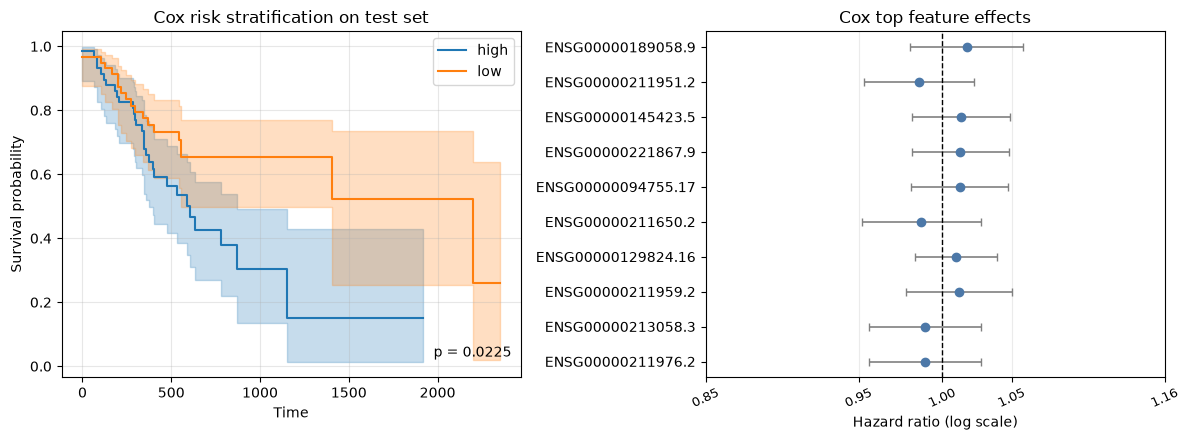

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_grouped_km_with_pvalue(cox_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[0])
axes[0].set_title('Cox risk stratification on test set')
plot_feature_importance(cox.hazard_ratios, ax=axes[1], top_n=10)
axes[1].set_title('Cox top feature effects')
plt.tight_layout()
plt.show()


## 4. Train LASSO-Cox with workflow-equivalent CV

这一部分对齐 `scripts/train_lasso.py`。


In [8]:
lasso_candidates = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1, 3e-1, 1.0]
lasso = LassoCoxModel(cv=5, random_state=42).fit_cv(
    train_df,
    'duration',
    'event',
    penalizers=lasso_candidates,
    n_repeats=3,
    use_one_se_rule=True,
)

lasso_selection_summary = getattr(lasso, 'selection_summary_', {})
lasso_summary = pd.DataFrame([
    {
        'model': 'lasso',
        'selected_penalizer': lasso.penalizer,
        'selected_rule': lasso_selection_summary.get('selected_rule'),
        'train_c_index': lasso.score(train_df),
        'test_c_index': lasso.score(test_df),
        'n_features': len(lasso.feature_cols or []),
        'selected_features': len(lasso.selected_features),
        'selected_cv_c_index': lasso_selection_summary.get('selected_mean_c_index'),
        'selected_cv_sem_c_index': lasso_selection_summary.get('selected_sem_c_index'),
        'selected_cv_mean_selected_features': lasso_selection_summary.get('selected_mean_selected_features'),
        'best_cv_c_index': lasso_selection_summary.get('best_mean_c_index'),
        'best_cv_mean_selected_features': lasso_selection_summary.get('best_mean_selected_features'),
    }
])
lasso_summary.to_csv(final_dir / 'lasso_summary.csv', index=False)
lasso.hazard_ratios.to_csv(final_dir / 'lasso_hazard_ratios.csv')
pd.DataFrame(lasso.selected_features, columns=['feature']).to_csv(final_dir / 'lasso_selected_features.csv', index=False)
getattr(lasso, 'cv_results_', pd.DataFrame()).to_csv(final_dir / 'lasso_penalizer_search.csv', index=False)
getattr(lasso, 'cv_fold_results_', pd.DataFrame()).to_csv(final_dir / 'lasso_penalizer_search_folds.csv', index=False)
getattr(lasso, 'feature_frequency_table_', pd.DataFrame()).to_csv(final_dir / 'lasso_feature_frequency.csv', index=False)

lasso_test = test_df.copy()
lasso_test['risk_score'] = lasso.predict_risk_score(test_df).values
lasso_test['risk_group'] = split_risk_group(lasso_test['risk_score'])
lasso_test.to_csv(final_dir / 'lasso_test_scored.csv', index=False)

lasso_summary


/home/zengj/workspace/miniconda3/envs/survivalnet/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(
/home/zengj/workspace/miniconda3/envs/survivalnet/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the lifelines documentation: https://lifelines.readthedocs.io/en/latest/Examples.html#problems-with-convergence-in-the-cox-proportional-hazard-model
  warnings.warn(
/home/zengj/workspace/miniconda3/envs/survivalnet/lib/python3.14/site-packages/lifelines/fitters/coxph_fitter.py:1614: ConvergenceWarning: Newton-Raphson failed to converge sufficiently. Please see the following tips in the life

,model,selected_penalizer,selected_rule,train_c_index,test_c_index,n_features,selected_features,selected_cv_c_index,selected_cv_sem_c_index,selected_cv_mean_selected_features,best_cv_c_index,best_cv_mean_selected_features
0,lasso,0.1,one_se,0.6039,0.5794,200,1,0.576295,0.014725,1.2,0.58454,1.533333


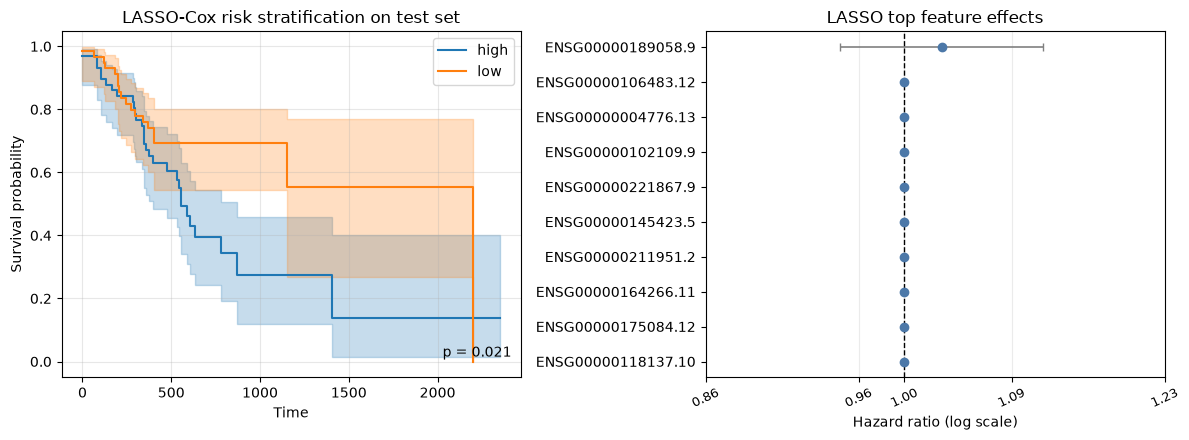

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plot_grouped_km_with_pvalue(lasso_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[0])
axes[0].set_title('LASSO-Cox risk stratification on test set')
plot_feature_importance(lasso.hazard_ratios, ax=axes[1], top_n=10)
axes[1].set_title('LASSO top feature effects')
plt.tight_layout()
plt.show()


## 5. Train DeepSurv with workflow-equivalent search

这一部分直接复用 `scripts/train_deepsurv.py` 中的候选构建、搜索、排序和 one-SE 选择逻辑。


In [10]:
hidden_dim1_grid = parse_int_grid('16,32,64')
hidden_dim2_grid = parse_int_grid('8,16,32')
dropout_grid = parse_float_grid('0.0,0.1,0.2')
learning_rate_grid = parse_float_grid('0.0001,0.0003,0.001')
batch_size_grid = parse_int_grid('16,32')

candidates = build_candidate_rows(
    hidden_dim1_grid,
    hidden_dim2_grid,
    dropout_grid,
    learning_rate_grid,
    batch_size_grid,
    batch_norm=True,
)
search_results, search_folds = evaluate_candidates(
    train_df,
    candidates,
    duration_col='duration',
    event_col='event',
    random_state=42,
    validation_split=0.1,
    epochs=80,
    patience=8,
    no_batch_norm=False,
    log_transform=True,
    max_features=120,
    min_expression_rate=0.05,
)
search_results = rank_results(search_results.drop_duplicates(
    subset=['hidden_dim1', 'hidden_dim2', 'dropout', 'learning_rate', 'batch_size', 'batch_norm'],
    keep='first',
).reset_index(drop=True))

best_row, selected_row = choose_row(search_results, use_one_se_rule=True)
readable_search = build_readable_search_table(search_results, selected_row=selected_row, best_row=best_row)

deep = DeepSurvModel(
    hidden_dim1=int(selected_row['hidden_dim1']),
    hidden_dim2=int(selected_row['hidden_dim2']),
    dropout=float(selected_row['dropout']),
    learning_rate=float(selected_row['learning_rate']),
    batch_size=int(selected_row['batch_size']),
    epochs=80,
    patience=8,
    validation_split=0.1,
    batch_norm=bool(selected_row['batch_norm']),
    log_transform=True,
    max_features=120,
    min_expression_rate=0.05,
    random_state=42,
).fit(train_df, 'duration', 'event')

deep_summary = pd.DataFrame([
    {
        'model': 'deep',
        'selected_rule': 'one_se',
        'selected_hidden_dim1': int(selected_row['hidden_dim1']),
        'selected_hidden_dim2': int(selected_row['hidden_dim2']),
        'selected_dropout': float(selected_row['dropout']),
        'selected_learning_rate': float(selected_row['learning_rate']),
        'selected_batch_size': int(selected_row['batch_size']),
        'selected_batch_norm': bool(selected_row['batch_norm']),
        'selected_cv_c_index': float(selected_row['mean_c_index']),
        'selected_cv_sem_c_index': float(selected_row['sem_c_index']),
        'selected_cv_n_parameters': int(selected_row['n_parameters']),
        'best_cv_c_index': float(best_row['mean_c_index']),
        'best_cv_n_parameters': int(best_row['n_parameters']),
        'train_c_index': deep.score(train_df),
        'test_c_index': deep.score(test_df),
        'n_features': len(deep.feature_cols or []),
        'status': 'ok',
    }
])

deep_summary.to_csv(final_dir / 'deepsurv_summary.csv', index=False)
search_results.to_csv(final_dir / 'deepsurv_search.csv', index=False)
readable_search.to_csv(final_dir / 'deepsurv_search_readable.csv', index=False)
search_folds.to_csv(final_dir / 'deepsurv_search_folds.csv', index=False)

deep_test = test_df.copy()
deep_test['deep_risk_score'] = deep.predict_risk_score(test_df).values
deep_test['risk_group'] = split_risk_group(deep_test['deep_risk_score'])
deep_test.to_csv(final_dir / 'deepsurv_test_scored.csv', index=False)

deep_summary


,model,selected_rule,selected_hidden_dim1,selected_hidden_dim2,selected_dropout,selected_learning_rate,selected_batch_size,selected_batch_norm,selected_cv_c_index,selected_cv_sem_c_index,selected_cv_n_parameters,best_cv_c_index,best_cv_n_parameters,train_c_index,test_c_index,n_features,status
0,deep,one_se,32,32,0.2,0.0003,32,True,0.562802,0.01748,5025,0.567884,5025,0.515573,0.593282,120,ok


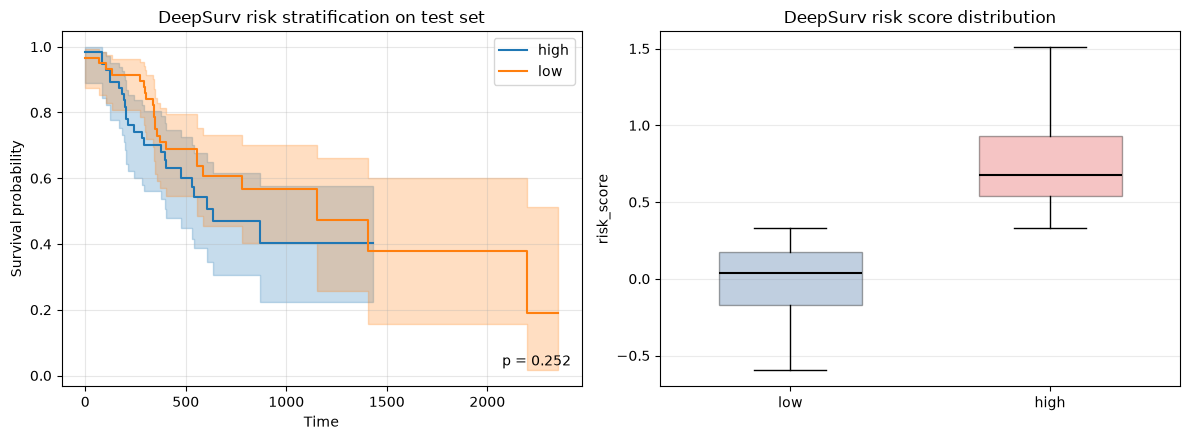

In [14]:

import importlib
import survivalnet.visualize as viz
importlib.reload(viz)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
viz.plot_grouped_km_with_pvalue(deep_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[0])
axes[0].set_title('DeepSurv risk stratification on test set')
viz.plot_risk_score_distribution(
    deep_test.rename(columns={'deep_risk_score': 'risk_score'}),
    'risk_score',
    ax=axes[1],
)
axes[1].set_title('DeepSurv risk score distribution')
plt.tight_layout()
plt.show()

## 6. Summarize results like the workflow


In [15]:
summary = pd.concat([
    pd.read_csv(final_dir / 'cox_summary.csv'),
    pd.read_csv(final_dir / 'lasso_summary.csv'),
    pd.read_csv(final_dir / 'deepsurv_summary.csv'),
], ignore_index=True)
summary.to_csv(final_dir / 'model_summary.csv', index=False)
summary


,model,selected_penalizer,selected_rule,train_c_index,test_c_index,n_features,selected_cv_c_index,selected_cv_sem_c_index,selected_cv_mean_selected_features,best_cv_c_index,...,selected_features,selected_hidden_dim1,selected_hidden_dim2,selected_dropout,selected_learning_rate,selected_batch_size,selected_batch_norm,selected_cv_n_parameters,best_cv_n_parameters,status
0,cox,1.5,one_se,0.747984,0.543309,200,0.535077,0.017625,197.133333,0.541468,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,lasso,0.1,one_se,0.603900,0.579400,200,0.576295,0.014725,1.200000,0.584540,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,deep,NaN,one_se,0.515573,0.593282,120,0.562802,0.017480,NaN,0.567884,...,NaN,32.0,32.0,0.2,0.0003,32.0,True,5025.0,5025.0,ok


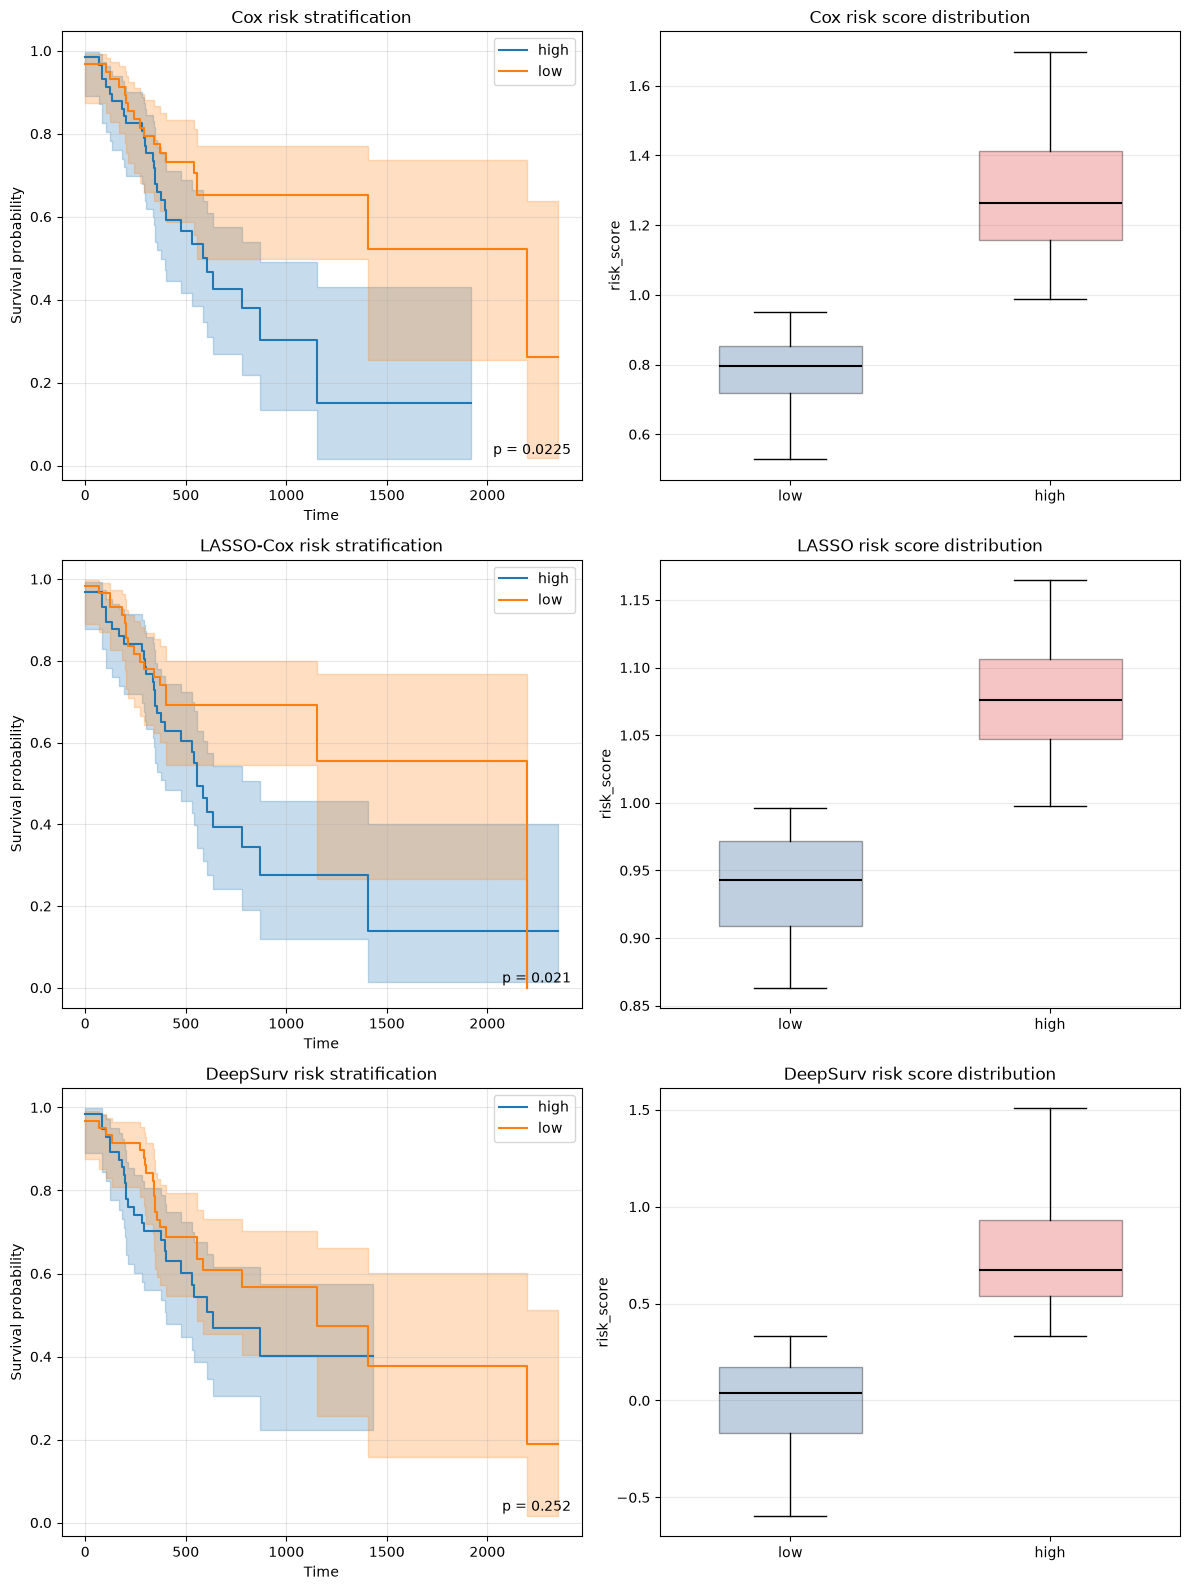

In [17]:
import importlib
import survivalnet.visualize as viz
importlib.reload(viz)

fig, axes = plt.subplots(3, 2, figsize=(12, 16))

viz.plot_grouped_km_with_pvalue(
    cox_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[0, 0]
)
axes[0, 0].set_title('Cox risk stratification')
viz.plot_risk_score_distribution(cox_test, 'risk_score', ax=axes[0, 1])
axes[0, 1].set_title('Cox risk score distribution')

viz.plot_grouped_km_with_pvalue(
    lasso_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[1, 0]
)
axes[1, 0].set_title('LASSO-Cox risk stratification')
viz.plot_risk_score_distribution(lasso_test, 'risk_score', ax=axes[1, 1])
axes[1, 1].set_title('LASSO risk score distribution')

viz.plot_grouped_km_with_pvalue(
    deep_test, 'duration', 'event', 'risk_group', 'low', 'high', ax=axes[2, 0]
)
axes[2, 0].set_title('DeepSurv risk stratification')
viz.plot_risk_score_distribution(
    deep_test.rename(columns={'deep_risk_score': 'risk_score'}),
    'risk_score',
    ax=axes[2, 1],
)
axes[2, 1].set_title('DeepSurv risk score distribution')

plt.tight_layout()
plt.show()
